# Introduction

This project is going to include binary classification, determining whether in a photo there is a cat or a dog. It's a learning project so there might appear comments which describe difficulties experienced in some sections or some things that I learned along the way which I consider relevant to that specific part.

### General Content

The project is going to include a single dataset which is then used to train 4 models in total. 1 which is plain CNN (commented out), and 3 which are built using transfer learning and fine tuning. The 3 backbone models chosen will be explained later in the "Transfer Learning & Fine Tuning" section. In the end there will be a comparison and analysis between the models followed by a personal recommendation on which one should be used.

### How is this useful?

The model can be used for apps that deal with animals, it can be adjusted so that it fits classification between multiple animals/objects. Even though it's not an advanced project by any means it can still serve as a basis for a larger one or at least for inspiration. In general this model can be used for learning/inspiration for other people without having anything to do with animals.

### How do cats differ from dogs visually?

Cats and dogs differ significantly in facial structure, body proportions, eye shapes, and paw anatomy. The models presented here will learn how to use this information (not specifically) in order to distinguish between the 2.


![picture of a dog with a cat](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR7V8ZtuqZUETy-kFrBl87TKtvxPKdSDVjSM7iPa5SDD4H0qVbv0xhezbA&s=10)

### Dataset used: 

- https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from PIL import Image

2026-06-27 19:37:16.950080: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782589037.146479      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782589037.199146      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782589037.694934      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782589037.694975      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782589037.694979      58 computation_placer.cc:177] computation placer alr

In [2]:
# Cats and Dogs Classification Dataset - referred to as ds

# Paths that will be relevant later on
ds_path = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages"

work_path = "/kaggle/working/"

num_classes = 2
IMG_SIZE = 224

# Making sure to save the plots
fig_save_path = os.path.join(work_path, 'plots')
os.makedirs(fig_save_path, exist_ok=True)

In [3]:
# Showing general information about the dataset: directories' names, number of samples

def num_samples_subdirs(dir_name):
    for sub_dir in os.listdir(dir_name):
        print(f"'{sub_dir}' num samples:{len(os.listdir(os.path.join(dir_name, sub_dir)))}")

print("Directory's names/num samples")
print("="*30)
dirs_ds = os.listdir(ds_path)
print(dirs_ds)
num_samples_subdirs(ds_path)
print("\n")

Directory's names/num samples
['Dog', 'Cat']
'Dog' num samples:12499
'Cat' num samples:12499




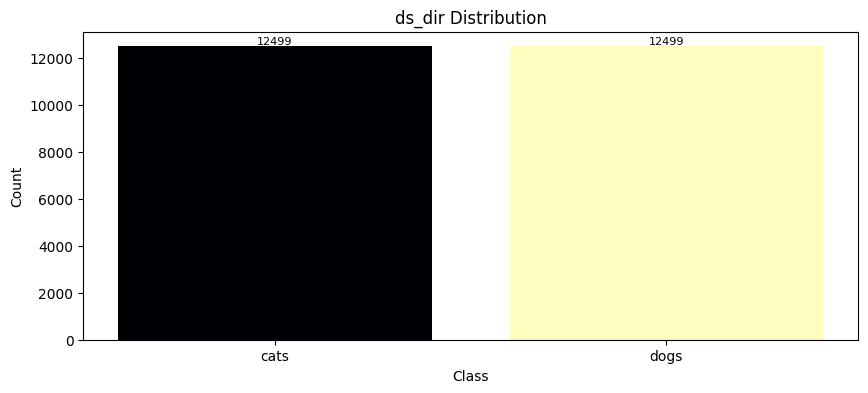

In [4]:
# Presenting the dataset's distribution

allowed_extensions = ('png', 'jpg', 'jpeg')

# Unpacking images, making sure that they have the allowed extensions
def unpack_images(e_dir, dir_path):
    for i, sub_dir_name in enumerate(sorted(os.listdir(dir_path))):
        curr_path = os.path.join(dir_path, sub_dir_name)
        curr_images = [c for c in os.listdir(curr_path) if c.endswith(allowed_extensions)]
        e_dir[i].extend([os.path.join(curr_path, l) for l in curr_images])

# The images will be saved in ds_dir in the format of [[cat],[dog]]
ds_dir = [[],[]]
unpack_images(ds_dir, ds_path)
ds_dir = np.array(ds_dir)

# Showing the distribution visually
def show_distribution(ds_dir, name='ds_dir'):
    cmap = plt.colormaps['magma']
    plt.figure(figsize=(10,4))
    colors = cmap(np.linspace(0, 1, num_classes))
    bars = plt.bar(['cats', 'dogs'], [len(l) for l in ds_dir], color=colors)
    plt.bar_label(bars, fontsize=8)
    plt.title(f'{name} Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.savefig(os.path.join(fig_save_path, name), dpi=150, bbox_inches='tight')
    plt.show()

show_distribution(ds_dir, 'ds_dir')

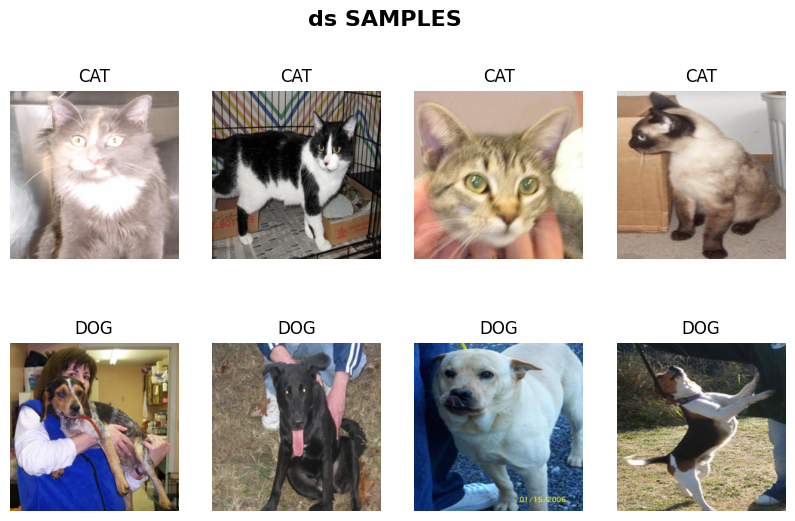

In [5]:
from PIL import Image

# Showing a few samples, we can see that these are not clean images, they were taken by normal people
# with their phones, the quality does not seem high. It's great data to work on since when making
# an application these are the types of photos that it usually gets.

NUM_SAMPLES = 8

def show_samples(curr_dir, dir_name=''):
    cat_random = np.random.choice(len(curr_dir[0]), NUM_SAMPLES//2, replace=False)
    dog_random = np.random.choice(len(curr_dir[1]), NUM_SAMPLES//2, replace=False)

    cat_random = curr_dir[0][cat_random]
    dog_random = curr_dir[1][dog_random]

    fig, axes = plt.subplots(2, 4, figsize=(10,6))
    fig.suptitle(f'{dir_name} SAMPLES', fontsize=16, fontweight='bold')
    axes = axes.flatten()
    
    for i, c_img in enumerate(cat_random):
        with Image.open(c_img) as im:
            img = (im.resize((IMG_SIZE, IMG_SIZE))).convert('RGB')
            axes[i].imshow(img)
            axes[i].set_title('CAT')
            axes[i].axis('off')

    for i, d_img in enumerate(dog_random):
        with Image.open(d_img) as im:
            img = (im.resize((IMG_SIZE, IMG_SIZE))).convert('RGB')
            axes[i+4].imshow(img)
            axes[i+4].set_title('DOG')
            axes[i+4].axis('off')

    plt.show()

show_samples(ds_dir, 'ds')

In [6]:
# Splitting the data in train/val/test with an 80/10/10 split. Making sure to save the images
# in the directory 'dataset' in the working directory. Need to watch out though since some of the 
# images have 2 channels, which will raise an error later when trying to train the model, in 
# order to solve it I convert to RGB and then save that version (more expensive).
import shutil
from tqdm import tqdm
import cv2

TRAIN_PER = 0.8
VAL_PER = 0.1
TEST_PER = 0.1

dataset_path = os.path.join(work_path, 'dataset')
os.makedirs(dataset_path, exist_ok=True)

train_path = os.path.join(dataset_path, 'train')
val_path = os.path.join(dataset_path, 'val')
test_path = os.path.join(dataset_path, 'test')

def shuffle_dir(curr_dir):
    for sub_dir in curr_dir:
        np.random.shuffle(sub_dir)

# Using starts in the case that some images have a problem opening, in that case they will be skipped
# something starts will take note of.
def make_split(starts, max_size, save_path):
    classes = ['cat', 'dog']
    for i, sub_dir in enumerate(ds_dir):
        c = 0
        while starts[i] < len(sub_dir) and c < max_size:
            img_path = sub_dir[starts[i]]
            try:
                img = Image.open(img_path)
                img = img.convert('RGB')
                img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
                save_path_img = os.path.join(save_path, classes[i], os.path.basename(img_path))
                cv2.imwrite(save_path_img, img)
                c += 1
            except Exception as e:
                print(f"Skipping {img_path}: {e}")
            starts[i] += 1

# To make sure we are not making the dataset again in case we are running the cell multiple times,
# helps making running the project faster when building.
DONE_MARKER = os.path.join(dataset_path, '.dataset_read')
if(os.path.exists(DONE_MARKER)):
    print("Dataset already exists, skipping rebuild.")
else:
    for split in [train_path, val_path, test_path]:
        for c_class in ['cat', 'dog']:
            path = os.path.join(split, c_class)
            os.makedirs(path, exist_ok=True)
    
    shuffle_dir(ds_dir)
    NUM_IMAGES_DS = 8000
    t1 = int(NUM_IMAGES_DS*TRAIN_PER)
    t2 = int(NUM_IMAGES_DS*VAL_PER)
    t3 = int(NUM_IMAGES_DS*TEST_PER)

    starts = [0,0]
    make_split(starts, t1, train_path)
    make_split(starts, t2, val_path)
    make_split(starts, t3, test_path)

    with open(DONE_MARKER, 'w') as f:
        f.write('done')

    print('='*30)
    print('DATASET IS FINISHED')
    print('='*30)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


DATASET IS FINISHED


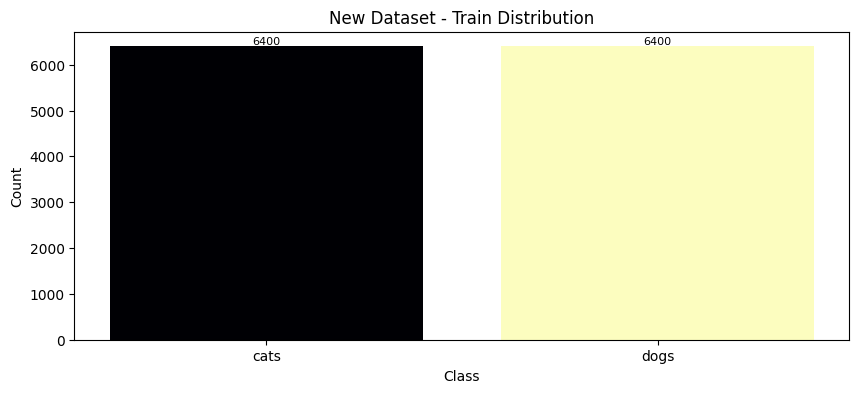

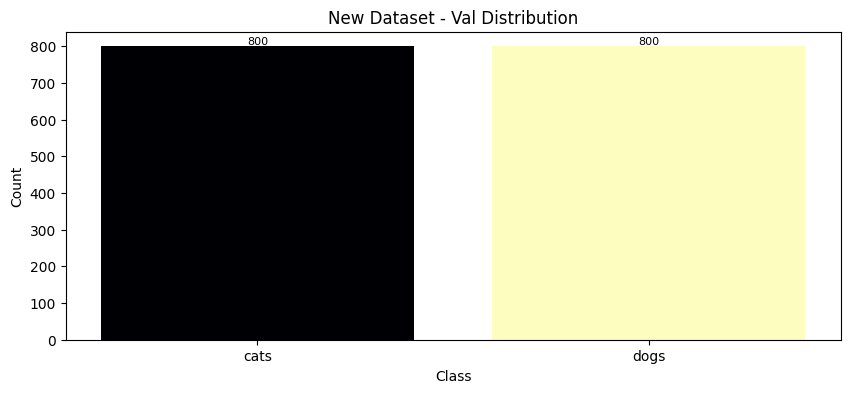

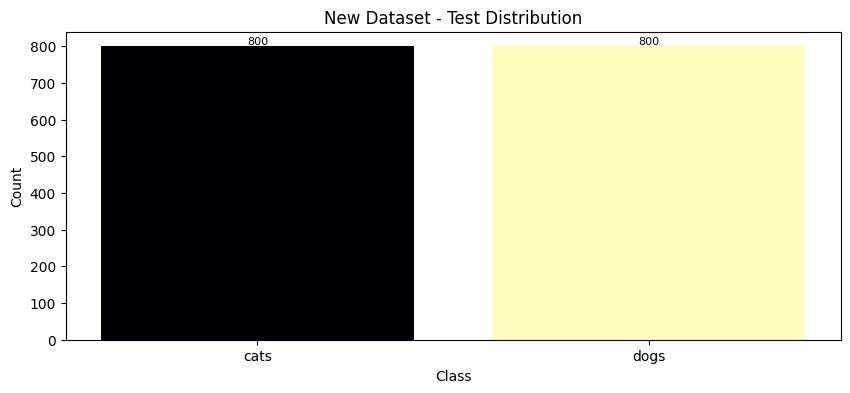

In [7]:
# Showing the new dataset's distribution

train = [os.listdir(os.path.join(train_path, 'cat')), os.listdir(os.path.join(train_path, 'dog'))]
val = [os.listdir(os.path.join(val_path, 'cat')), os.listdir(os.path.join(val_path, 'dog'))]
test = [os.listdir(os.path.join(test_path, 'cat')), os.listdir(os.path.join(test_path, 'dog'))]

show_distribution(train, 'New Dataset - Train')
show_distribution(val, 'New Dataset - Val')
show_distribution(test, 'New Dataset - Test')

In [8]:
BATCH_SIZE = 16

# Since I will be using a single neuron with activation sigmoid I need to work with integers
# so I switched from label_mode being "categorical" to "binary" so that it doesn't one hot encode it
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    label_mode='binary',
    shuffle=True,
    seed=2,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    label_mode='binary',
    shuffle=False,
    seed=2,
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    label_mode='binary',
    shuffle=False,
    seed=2,
)

class_names = train_ds.class_names
class_to_index = {c: i for i, c in enumerate(class_names)}
index_to_class = {i: c for i, c in enumerate(class_names)}

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

Found 12800 files belonging to 2 classes.


I0000 00:00:1782589202.671293      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 1600 files belonging to 2 classes.
Found 1600 files belonging to 2 classes.


## Evaluation Function

### Metrics:


* Accuracy
* F1 Score
* Precision
* Recall
* ROC-AUC
* Inference(ms/sample)
* Model Size(MB)

In [9]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, model_name, hist, model_path, label1='Phase 1', hist2=None, label2='Phase 2'):
    loss, accuracy = model.evaluate(test_ds, verbose=0)
    print(f"loss: {loss:.4f} accuracy: {accuracy*100:.2f}%")

    t_start = time.time()
    y_pred_proba = model.predict(test_ds, verbose=0).flatten()
    inference_time = time.time() - t_start
    n_samples = len(y_pred_proba)
    time_per_sample_ms = (inference_time / n_samples) * 1000
    y_pred = (y_pred_proba >= 0.5).astype(int)
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int).flatten()

    classes = list(index_to_class.values())

    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    roc_auc   = roc_auc_score(y_true, y_pred_proba)

    # Dividing by 1024 * 1024 to get it in MB
    model_size_mb = os.path.getsize(model_path) / (1024 * 1024)    

    print(f"\n{'='*40}")
    print(f"  Accuracy:    {accuracy:.4f}")
    print(f"  F1 Score:    {f1:.4f}")
    print(f"  Precision:   {precision:.4f}")
    print(f"  Recall:      {recall:.4f}")
    print(f"  ROC-AUC:     {roc_auc:.4f}")
    print(f"  Inference:   {inference_time:.2f}s total | {time_per_sample_ms:.2f}ms/sample")
    print(f"  Model Size:     {model_size_mb:.4f}MB")
    print(f"{'='*40}\n")
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    h1_epochs = range(1, len(hist.history['loss']) + 1)
    offset = len(hist.history['loss'])
    if hist2:
        h2_epochs = range(offset + 1, offset + len(hist2.history['loss']) + 1)

    fig, axes = plt.subplots(3, 2, figsize=(16, 22))
    fig.suptitle(f"{model_name} RESULTS", fontsize=16, fontweight='bold')

    # --- Loss ---
    axes[0, 0].plot(h1_epochs, hist.history['loss'], label=f'{label1} train')
    axes[0, 0].plot(h1_epochs, hist.history['val_loss'], label=f'{label1} valid')
    if hist2:
        axes[0, 0].plot(h2_epochs, hist2.history['loss'], label=f'{label2} train')
        axes[0, 0].plot(h2_epochs, hist2.history['val_loss'], label=f'{label2} valid')
        axes[0, 0].axvline(x=offset, color='gray', linestyle='--', alpha=0.5, label='Phase split')
    axes[0, 0].legend(); axes[0, 0].set_title('Loss', fontsize=14)
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')

    # --- Accuracy ---
    axes[0, 1].plot(h1_epochs, hist.history['accuracy'], label=f'{label1} train')
    axes[0, 1].plot(h1_epochs, hist.history['val_accuracy'], label=f'{label1} valid')
    if hist2:
        axes[0, 1].plot(h2_epochs, hist2.history['accuracy'], label=f'{label2} train')
        axes[0, 1].plot(h2_epochs, hist2.history['val_accuracy'], label=f'{label2} valid')
        axes[0, 1].axvline(x=offset, color='gray', linestyle='--', alpha=0.5, label='Phase split')
    axes[0, 1].legend(); axes[0, 1].set_title('Accuracy', fontsize=14)
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')

    # --- Confusion Matrix ---
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1, 0],
                xticklabels=classes, yticklabels=classes)
    axes[1, 0].set_xlabel('Predicted'); axes[1, 0].set_ylabel('Actual')
    axes[1, 0].set_title('Confusion Matrix (normalized)', fontsize=14)

    # --- Metrics Summary ---
    metrics = ['Accuracy', 'F1', 'Precision', 'Recall', 'ROC-AUC']
    values  = [accuracy, f1, precision, recall, roc_auc]
    colors  = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple']
    bars = axes[1, 1].bar(metrics, values, color=colors)
    axes[1, 1].set_ylim(0, 1.1); axes[1, 1].set_title('Metrics Summary', fontsize=14)
    for bar, val in zip(bars, values):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{val:.3f}', ha='center', fontsize=9)

    # --- ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    axes[2, 0].plot(fpr, tpr, label=f'(AUC={roc_auc:.2f})')
    axes[2, 0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    axes[2, 0].set_xlabel('FPR'); axes[2, 0].set_ylabel('TPR')
    axes[2, 0].set_title(f'ROC Curve (AUC={roc_auc:.3f})', fontsize=14)
    axes[2, 0].legend(loc='lower right', fontsize=8)

    # --- Per-class F1 bar chart ---
    per_class_f1 = f1_score(y_true, y_pred, average=None)
    colors_bar = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    axes[2, 1].bar(classes, per_class_f1, color=colors_bar)
    axes[2, 1].set_ylim(0, 1.1); axes[2, 1].set_title('Per-class F1 Score', fontsize=14)
    axes[2, 1].set_xlabel('Class'); axes[2, 1].set_ylabel('F1')
    for i, val in enumerate(per_class_f1):
        axes[2, 1].text(i, val + 0.01, f'{val:.3f}', ha='center', va='bottom',
                        fontsize=9, rotation=60)

    plt.tight_layout()
    plt.show()

# CNN Model

### Important - Why the CNN doesn't work

When trying to train the CNN model it stayed at 50% accuracy for both training and validation. The reason I suspect it happened is vanishing gradient. 

Since the model that I built was very large, it was likely that the earlier layers were not updated causing the model to stay with random initialized weights. 

One of the solutions would be to make a smaller model, which is how I found out that the problem was the size of the model, since a smaller version worked. Of the other possible things that can be done to help fix this problem I also tried to use he initialization for the weights and also batch normalization, however it didn't fix the problem.

From what I found, fixing the problem of vanishing gradient can be used with residual connections, something that I've decided not to do, but will in future projects since it could be very helpful for the model, and I also find it very interesting since it's very effective. One of the other solutions which was applied later on is to simply use a pretrained backbone, which appears in the next section of "Transfer Learning & Fine Tuning".

In [10]:
# from tensorflow.keras.layers import(
#     Conv2D, BatchNormalization, Dense, Dropout, GlobalAveragePooling2D, Input, ReLU, MaxPooling2D,
#     RandomBrightness, RandomFlip, RandomRotation, RandomZoom, Rescaling
# )
# from keras.models import Model

# def cnn_block(x, filters):
#     x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
#     x = BatchNormalization()(x)
#     x = ReLU()(x)
#     x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
#     x = BatchNormalization()(x)
#     x = ReLU()(x)
#     x = MaxPooling2D()(x)
#     return x

# def build_cnn_model():
#     inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
#     # Rescaling always applied (train + val)
#     x = Rescaling(1./255)(inputs)
    
#     # Augmentation only during training (Keras handles this automatically when use_training=True)
#     x = RandomBrightness(0.1)(x)
#     x = RandomFlip(mode='horizontal')(x)
#     x = RandomRotation(0.1, fill_mode='nearest')(x)
#     x = RandomZoom(0.1, fill_mode='nearest')(x)
    
#     x = cnn_block(x, 32)
#     x = cnn_block(x, 64)
#     x = cnn_block(x, 128)
#     x = cnn_block(x, 256)
#     x = cnn_block(x, 512)
#     x = GlobalAveragePooling2D()(x)
#     x = Dense(128, activation='relu')(x)
#     x = Dropout(0.5)(x)
#     outputs = Dense(1, activation='sigmoid')(x)
#     return Model(inputs, outputs)

# cnn_model = build_cnn_model()
# cnn_model.summary()

In [11]:
# cnn_model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=1e-4),
#     loss=tf.keras.losses.BinaryCrossentropy(),
#     metrics=['accuracy']
# )

# cnn_best_model_path = os.path.join(work_path, 'best_models', 'cnn.weights.h5')

# callbacks = [
#     tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5), 
#     tf.keras.callbacks.ModelCheckpoint(
#         cnn_best_model_path,
#         monitor='val_loss',
#         save_best_only=True,
#         save_weights_only=True
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
# ]

# CNN_EPOCHS = 100

# history = cnn_model.fit(
#     train_ds,
#     epochs=CNN_EPOCHS,
#     validation_data=val_ds,
#     callbacks=callbacks
# )

# cnn_model.load_weights(cnn_best_model_path)

# evaluate_model(cnn_model, 'CNN Model', history)

# Transfer Learning & Fine Tuning

### Backbone models chosen:

#### MobileNetV2 
- Reliable, fast, very light. Great choice since it achieves considerable accuracy while at the same time not being too heavy which makes it a very good choice for mobile devices.

#### EfficientNetV2B1 
- Heavier than MobileNetV2 but compensates with higher accuracy for it, also slower than MobileNetV2 however not by too much so it's still a good choice for mobile devices, I chose it since I wanted to also show a model that prioritizes accuracy over speed and weight.

#### InceptionV3
- Heavier than MobileNetV2 and EfficientNetV2B1 it's an interesting choice since it's higher in terms of accuracy than MobileNetV2 but not far away when it comes to inference so I'm intrigued to try it out.

all backbone models chosen do not exceed in size 150MB and have inference time of less than 10ms (except EfficientNetV2B1 in which it's not specified) according to keras applications table (https://keras.io/api/applications/)

In [12]:
# Making directories for saving best model and models

os.makedirs(os.path.join(work_path, 'models'), exist_ok=True)
os.makedirs(os.path.join(work_path, 'best_models'), exist_ok=True)

### Transfer Learning Function

In [13]:
import tensorflow
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def transfer_learning(base_model, preprocess_input, best_model_save_path, model_save_path):
    NUM_EPOCHS_PHASE1 = 10
    input_shape = (IMG_SIZE, IMG_SIZE, 3)

    base_model = base_model(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False
    
    inputs  = Input(shape=input_shape)
    x       = preprocess_input(inputs)
    x       = base_model(x)
    x       = GlobalAveragePooling2D()(x)
    x       = Dense(128, activation='relu')(x)
    x       = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model   = Model(inputs, outputs)

    # I've decided to use label smoothing since cats and dogs do look similar in some aspects.
    # It's a regularization technique that helps reduce overconfidence in the model
    model.compile(
        optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tensorflow.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    model.summary()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5), 
        tf.keras.callbacks.ModelCheckpoint(
            best_model_save_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=True,
            verbose=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=NUM_EPOCHS_PHASE1,
        callbacks=callbacks
    )

    model.load_weights(best_model_save_path)
    model.save(model_save_path)

    return model, history

### Fine Tuning Function

In [14]:
def fine_tuning(model, NUM_UNFREEZE_LAYERS, best_model_save_path, model_save_path):
    NUM_EPOCHS_PHASE2 = 20
    base_model_loaded = model.layers[1]
    base_model_loaded.trainable=True

    for layer in base_model_loaded.layers[:-1 * NUM_UNFREEZE_LAYERS]:
        layer.trainable = False

    model.compile(
        optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-4),
        loss=tensorflow.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5), 
        tf.keras.callbacks.ModelCheckpoint(
            best_model_save_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=True,
            verbose=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=NUM_EPOCHS_PHASE2,
        callbacks=callbacks
    )

    model.load_weights(best_model_save_path)
    model.save(model_save_path)

    return model, history

## MobileNetV2

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

best_model_save_path_mobilenetv2 = os.path.join(work_path, 'best_model', 'mobilenetv2.weights.h5')
model_save_path_mobilenetv2 = os.path.join(work_path, 'models', 'mobilenetv2.keras')

print("="*50)
print("TRANSFER LEARNING")
print("="*50)

mobilenetv2_model, history1 = transfer_learning(
    MobileNetV2,
    preprocess_input,
    best_model_save_path_mobilenetv2,
    model_save_path_mobilenetv2
)

print("="*50)
print("FINE TUNING")
print("="*50)

mobilenetv2_model, history2 = fine_tuning(
    mobilenetv2_model,
    40,
    best_model_save_path_mobilenetv2,
    model_save_path_mobilenetv2
)

TRANSFER LEARNING
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

...

Epoch 1/10


I0000 00:00:1782589211.865081     143 service.cc:152] XLA service 0x7b3f98003190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782589211.865120     143 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782589213.004789     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782589219.294341     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


799/800 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9686 - loss: 0.2779
Epoch 1: val_loss improved from None to 0.22582, saving model to /kaggle/working/best_model/mobilenetv2.weights.h5

Epoch 1: finished saving model to /kaggle/working/best_model/mobilenetv2.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.9806 - loss: 0.2511 - val_accuracy: 0.9900 - val_loss: 0.2258 - learning_rate: 0.0010
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9889 - loss: 0.2330
Epoch 2: val_loss improved from 0.22582 to 0.22250, saving model to /kaggle/working/best_model/mobilenetv2.weights.h5

Epoch 2: finished saving model to /kaggle/working/best_model/mobilenetv2.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9888 - loss: 0.2326 - val_accuracy: 0.9906 - val_loss: 0.2225 - learning_rate: 0.0010
Epoch 3/10
797/800 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9920 - loss: 0.2284
Epoch 3: val_loss did not improve from 0.22250
800/800 ━━━━━━

2026-06-27 19:42:53.330533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 19:42:53.526301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9622 - loss: 0.2759
Epoch 1: val_loss improved from None to 0.26641, saving model to /kaggle/working/best_model/mobilenetv2.weights.h5

Epoch 1: finished saving model to /kaggle/working/best_model/mobilenetv2.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9721 - loss: 0.2593 - val_accuracy: 0.9787 - val_loss: 0.2664 - learning_rate: 1.0000e-04
Epoch 2/20
797/800 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9905 - loss: 0.2271
Epoch 2: val_loss improved from 0.26641 to 0.24120, saving model to /kaggle/working/best_model/mobilenetv2.weights.h5

Epoch 2: finished saving model to /kaggle/working/best_model/mobilenetv2.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.9932 - loss: 0.2230 - val_accuracy: 0.9837 - val_loss: 0.2412 - learning_rate: 1.0000e-04
Epoch 3/20
797/800 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9963 - loss: 0.2168
Epoch 3: val_loss improved from 0.24120 to 0.23899, s

loss: 0.2179 accuracy: 99.00%

  Accuracy:    0.9900
  F1 Score:    0.9900
  Precision:   0.9901
  Recall:      0.9900
  ROC-AUC:     0.9984
  Inference:   6.13s total | 3.83ms/sample
  Model Size:     23.9162MB

              precision    recall  f1-score   support

         cat       1.00      0.98      0.99       800
         dog       0.98      1.00      0.99       800

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600



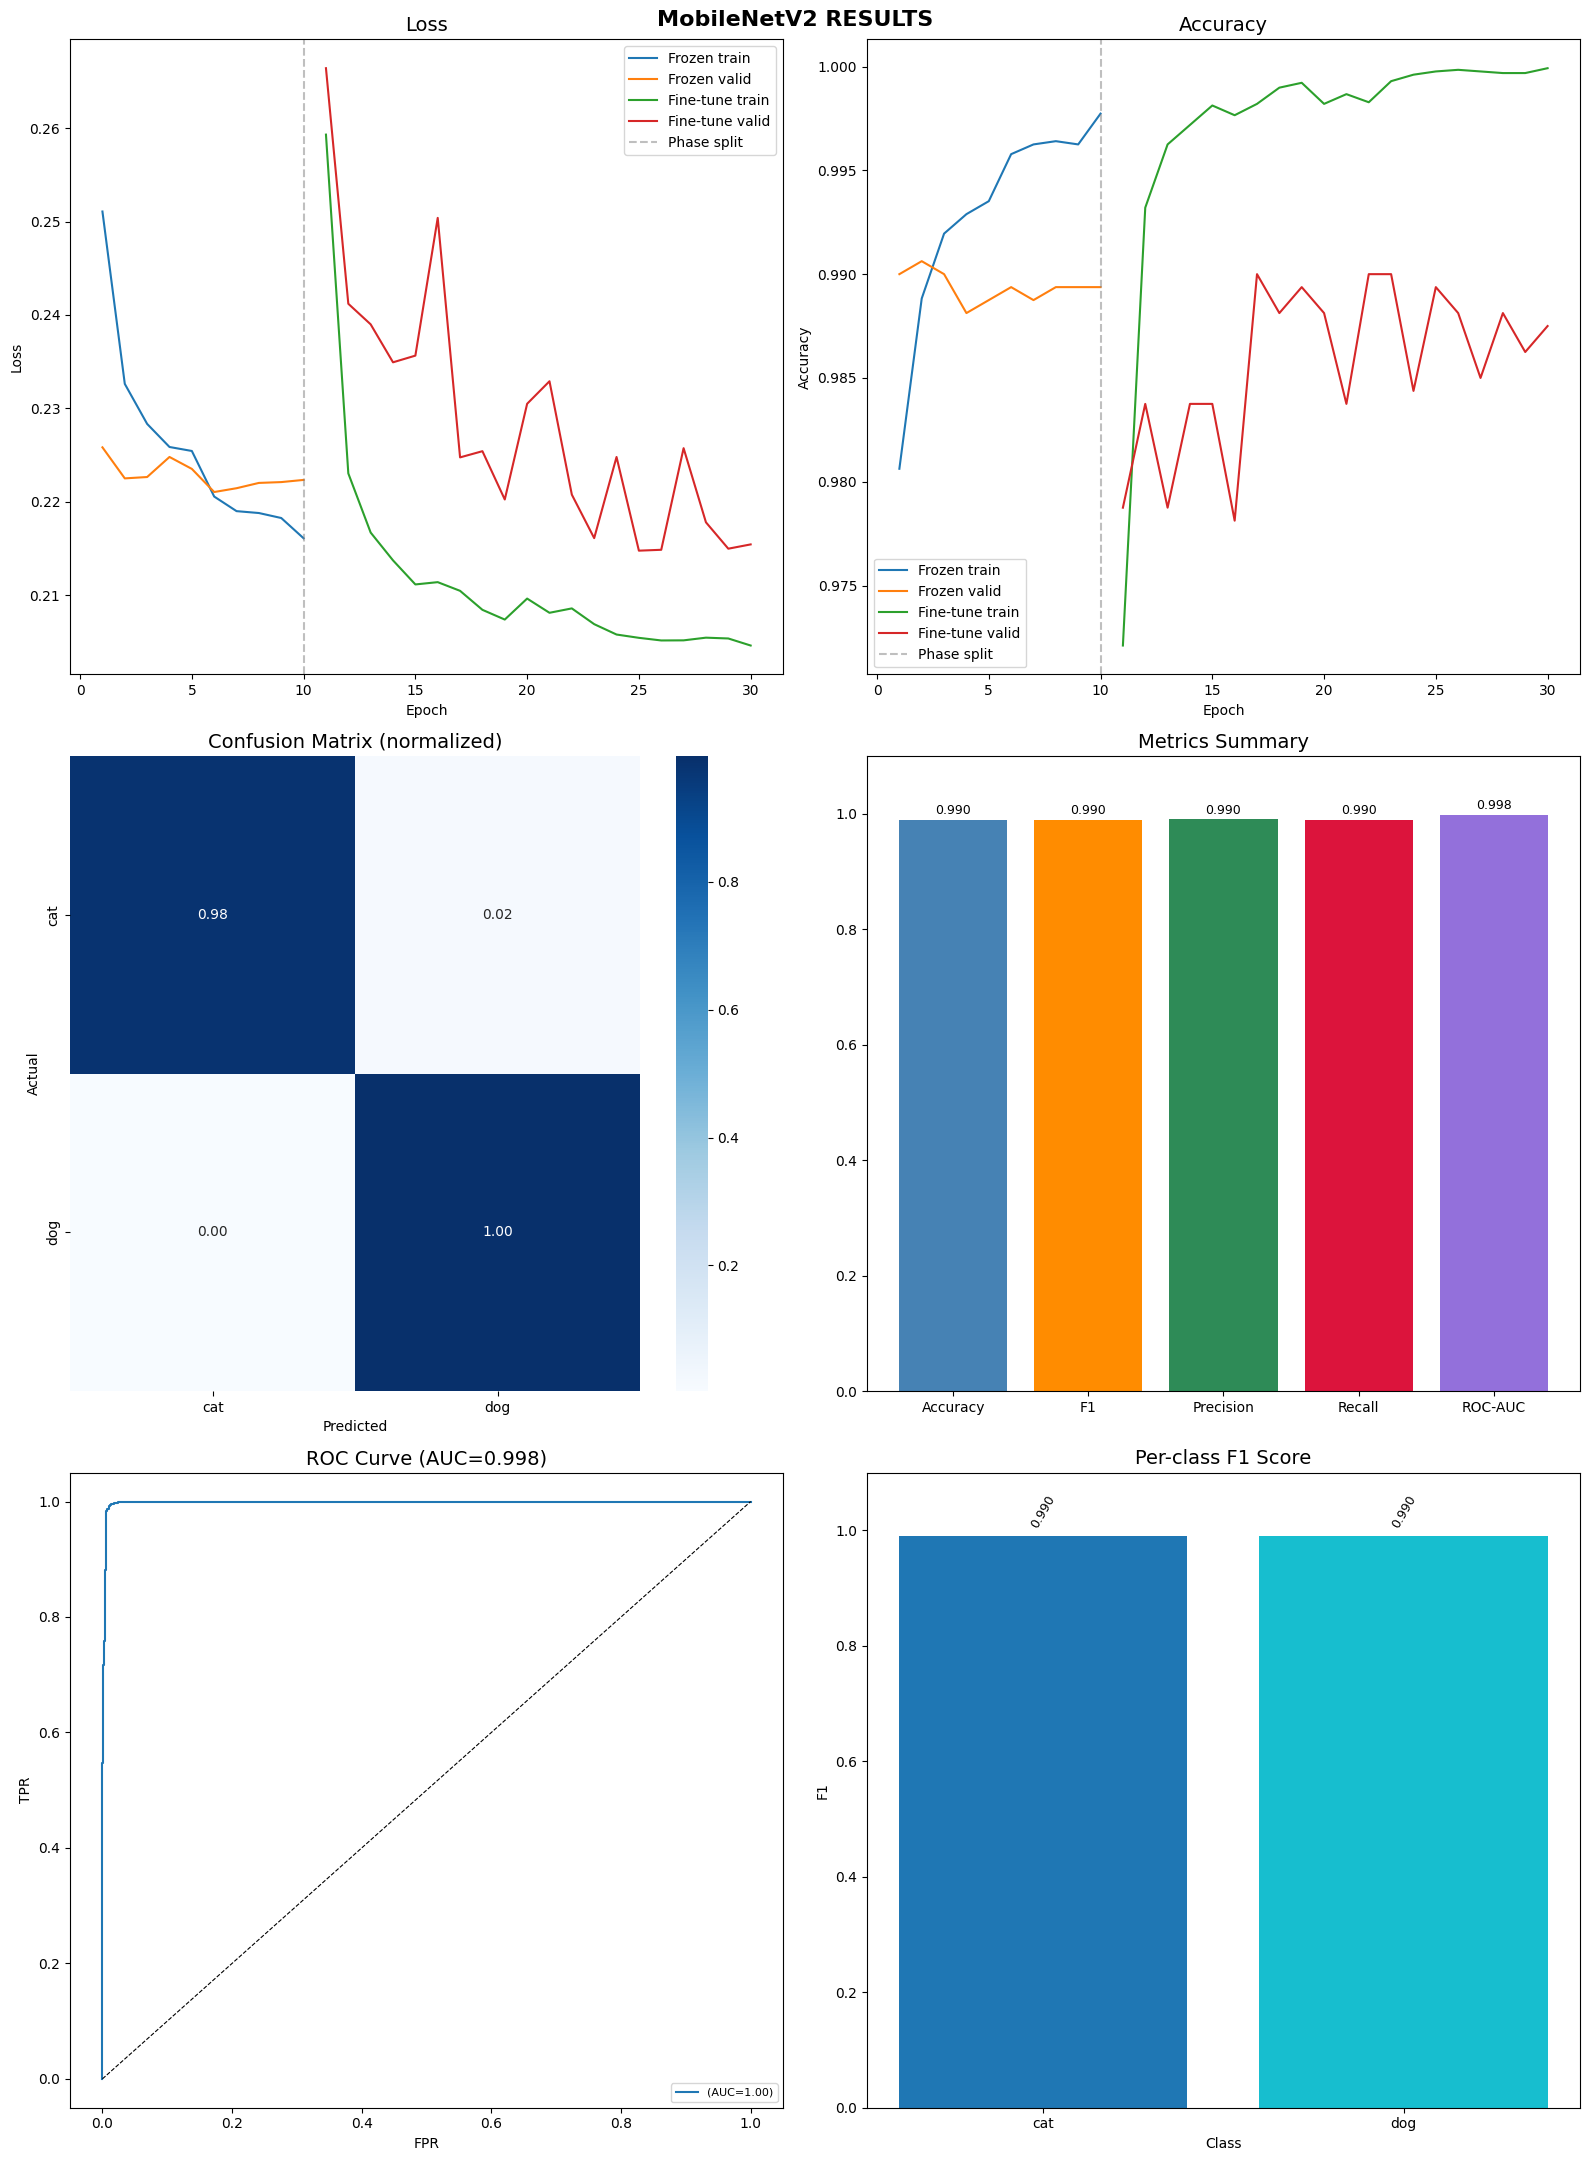

In [16]:
evaluate_model(mobilenetv2_model, "MobileNetV2", history1, model_save_path_mobilenetv2,label1='Frozen', hist2=history2, label2='Fine-tune')

## EfficientNetV2B1

In [17]:
from tensorflow.keras.applications import EfficientNetV2B1
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

best_model_save_path_efficientnetv2b1 = os.path.join(work_path, 'best_model', 'efficientnetv2b1.weights.h5')
model_save_path_efficientnetv2b1 = os.path.join(work_path, 'models', 'efficientnetv2b1.keras')

print("="*50)
print("TRANSFER LEARNING")
print("="*50)

efficientnetv2b1_model, history1 = transfer_learning(
    EfficientNetV2B1,
    preprocess_input,
    best_model_save_path_efficientnetv2b1,
    model_save_path_efficientnetv2b1
)

print("="*50)
print("FINE TUNING")
print("="*50)

efficientnetv2b1_model, history2 = fine_tuning(
    efficientnetv2b1_model,
    40,
    best_model_save_path_efficientnetv2b1,
    model_save_path_efficientnetv2b1
)

TRANSFER LEARNING
28456008/28456008 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b1 (Functional)  │ (None, 7, 7, 1280)     │     6,931,124 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,095,221 (27.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 6,931,124 (26.44 MB)

Epoch 1/10
799/800 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9784 - loss: 0.2473
Epoch 1: val_loss improved from None to 0.21116, saving model to /kaggle/working/best_model/efficientnetv2b1.weights.h5

Epoch 1: finished saving model to /kaggle/working/best_model/efficientnetv2b1.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9892 - loss: 0.2321 - val_accuracy: 0.9956 - val_loss: 0.2112 - learning_rate: 0.0010
Epoch 2/10
798/800 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9935 - loss: 0.2215
Epoch 2: val_loss did not improve from 0.21116
800/800 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9941 - loss: 0.2215 - val_accuracy: 0.9956 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9938 - loss: 0.2192
Epoch 3: val_loss did not improve from 0.21116
800/800 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.9945 - loss: 0.2187 - val_accuracy: 0.9944 - val_loss: 0.2112 - learning_rate: 0.0010
Epoch 

2026-06-27 19:54:45.292787: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 19:54:45.497580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


799/800 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9926 - loss: 0.2269
Epoch 1: val_loss improved from None to 0.21125, saving model to /kaggle/working/best_model/efficientnetv2b1.weights.h5

Epoch 1: finished saving model to /kaggle/working/best_model/efficientnetv2b1.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 78s 43ms/step - accuracy: 0.9933 - loss: 0.2224 - val_accuracy: 0.9931 - val_loss: 0.2112 - learning_rate: 1.0000e-04
Epoch 2/20
798/800 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9963 - loss: 0.2153
Epoch 2: val_loss improved from 0.21125 to 0.20898, saving model to /kaggle/working/best_model/efficientnetv2b1.weights.h5

Epoch 2: finished saving model to /kaggle/working/best_model/efficientnetv2b1.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.9962 - loss: 0.2147 - val_accuracy: 0.9950 - val_loss: 0.2090 - learning_rate: 1.0000e-04
Epoch 3/20
798/800 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9970 - loss: 0.2117
Epoch 3: val_loss improved from 0

loss: 0.2117 accuracy: 99.25%

  Accuracy:    0.9925
  F1 Score:    0.9925
  Precision:   0.9925
  Recall:      0.9925
  ROC-AUC:     0.9990
  Inference:   9.25s total | 5.78ms/sample
  Model Size:     42.6043MB

              precision    recall  f1-score   support

         cat       1.00      0.99      0.99       800
         dog       0.99      1.00      0.99       800

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600



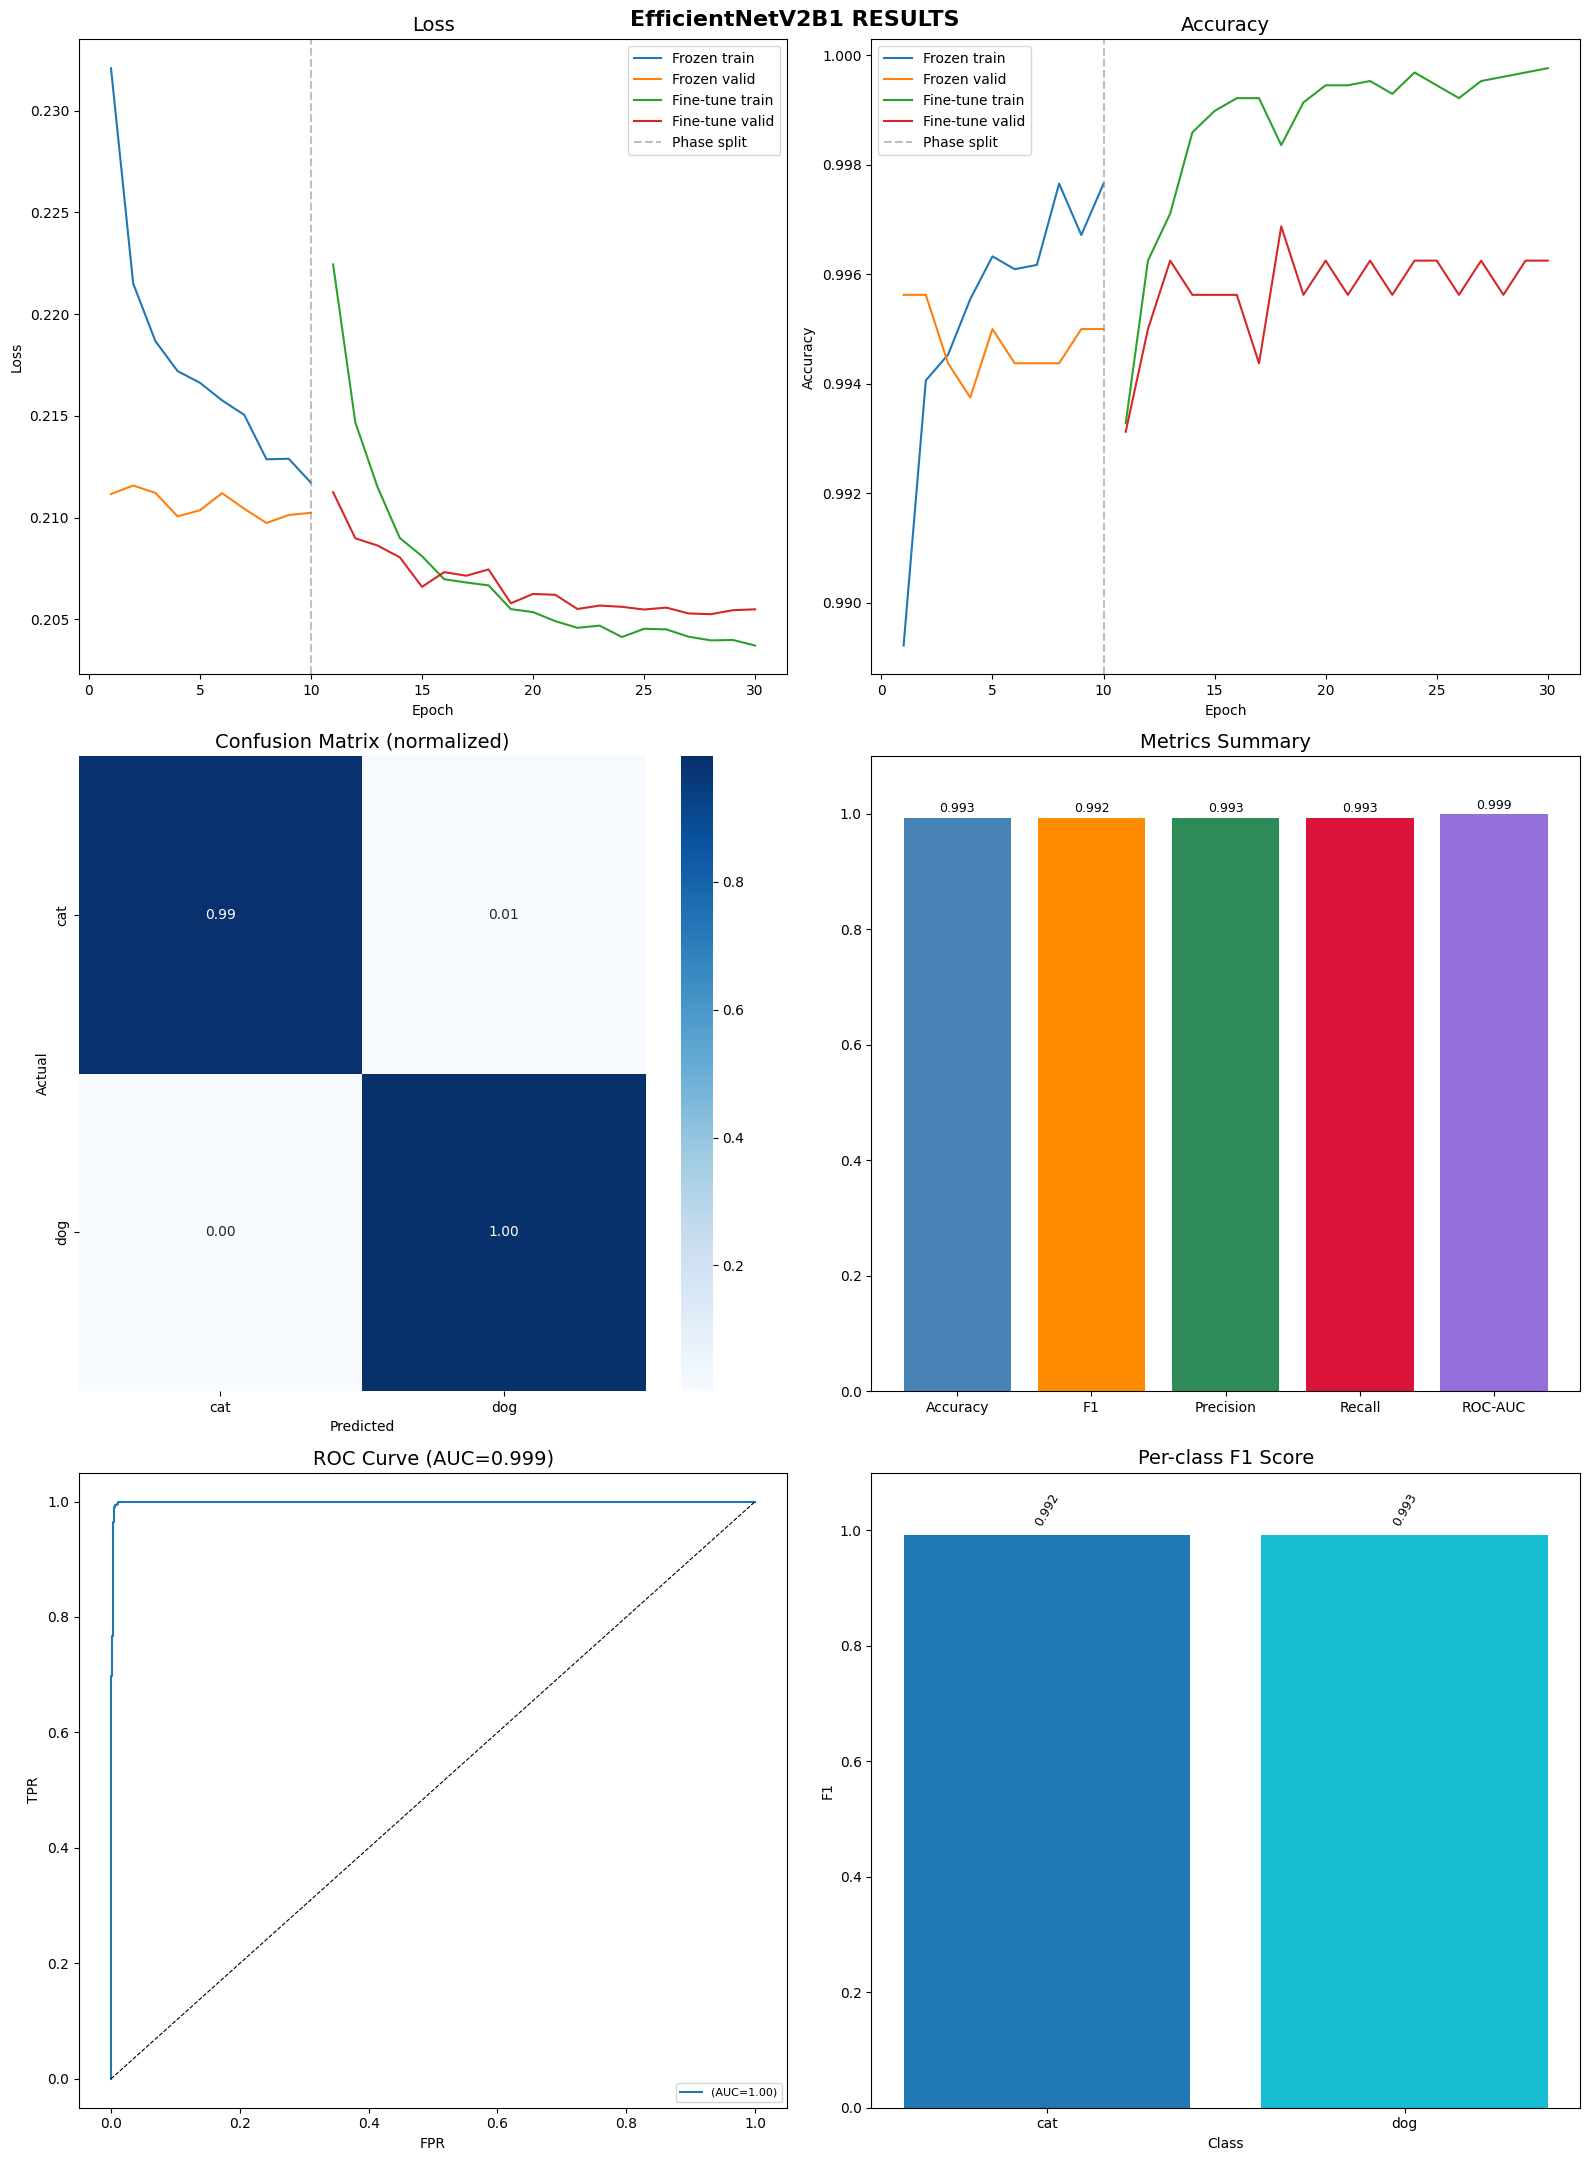

In [18]:
evaluate_model(efficientnetv2b1_model, "EfficientNetV2B1", history1, model_save_path_efficientnetv2b1,label1='Frozen', hist2=history2, label2='Fine-tune')

## InceptionV3

In [19]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

best_model_save_path_inceptionv3 = os.path.join(work_path, 'best_model', 'inceptionv3.weights.h5')
model_save_path_inceptionv3 = os.path.join(work_path, 'models', 'inceptionv3.keras')

print("="*50)
print("TRANSFER LEARNING")
print("="*50)

inceptionv3_model, history1 = transfer_learning(
    InceptionV3,
    preprocess_input,
    best_model_save_path_inceptionv3,
    model_save_path_inceptionv3
)

print("="*50)
print("FINE TUNING")
print("="*50)

inceptionv3_model, history2 = fine_tuning(
    inceptionv3_model,
    50,
    best_model_save_path_inceptionv3,
    model_save_path_inceptionv3
)

TRANSFER LEARNING
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,185 (84.17 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/10
799/800 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9709 - loss: 0.2780
Epoch 1: val_loss improved from None to 0.22785, saving model to /kaggle/working/best_model/inceptionv3.weights.h5

Epoch 1: finished saving model to /kaggle/working/best_model/inceptionv3.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 51s 43ms/step - accuracy: 0.9834 - loss: 0.2517 - val_accuracy: 0.9900 - val_loss: 0.2279 - learning_rate: 0.0010
Epoch 2/10
799/800 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9891 - loss: 0.2370
Epoch 2: val_loss improved from 0.22785 to 0.21992, saving model to /kaggle/working/best_model/inceptionv3.weights.h5

Epoch 2: finished saving model to /kaggle/working/best_model/inceptionv3.weights.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9895 - loss: 0.2352 - val_accuracy: 0.9912 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 3/10
799/800 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9913 - loss: 0.2331
Epoch 3: val_loss improved from 0.21992 to 0.21828

loss: 0.2178 accuracy: 99.12%

  Accuracy:    0.9912
  F1 Score:    0.9912
  Precision:   0.9913
  Recall:      0.9912
  ROC-AUC:     0.9977
  Inference:   9.70s total | 6.06ms/sample
  Model Size:     141.9749MB

              precision    recall  f1-score   support

         cat       0.99      0.99      0.99       800
         dog       0.99      0.99      0.99       800

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600



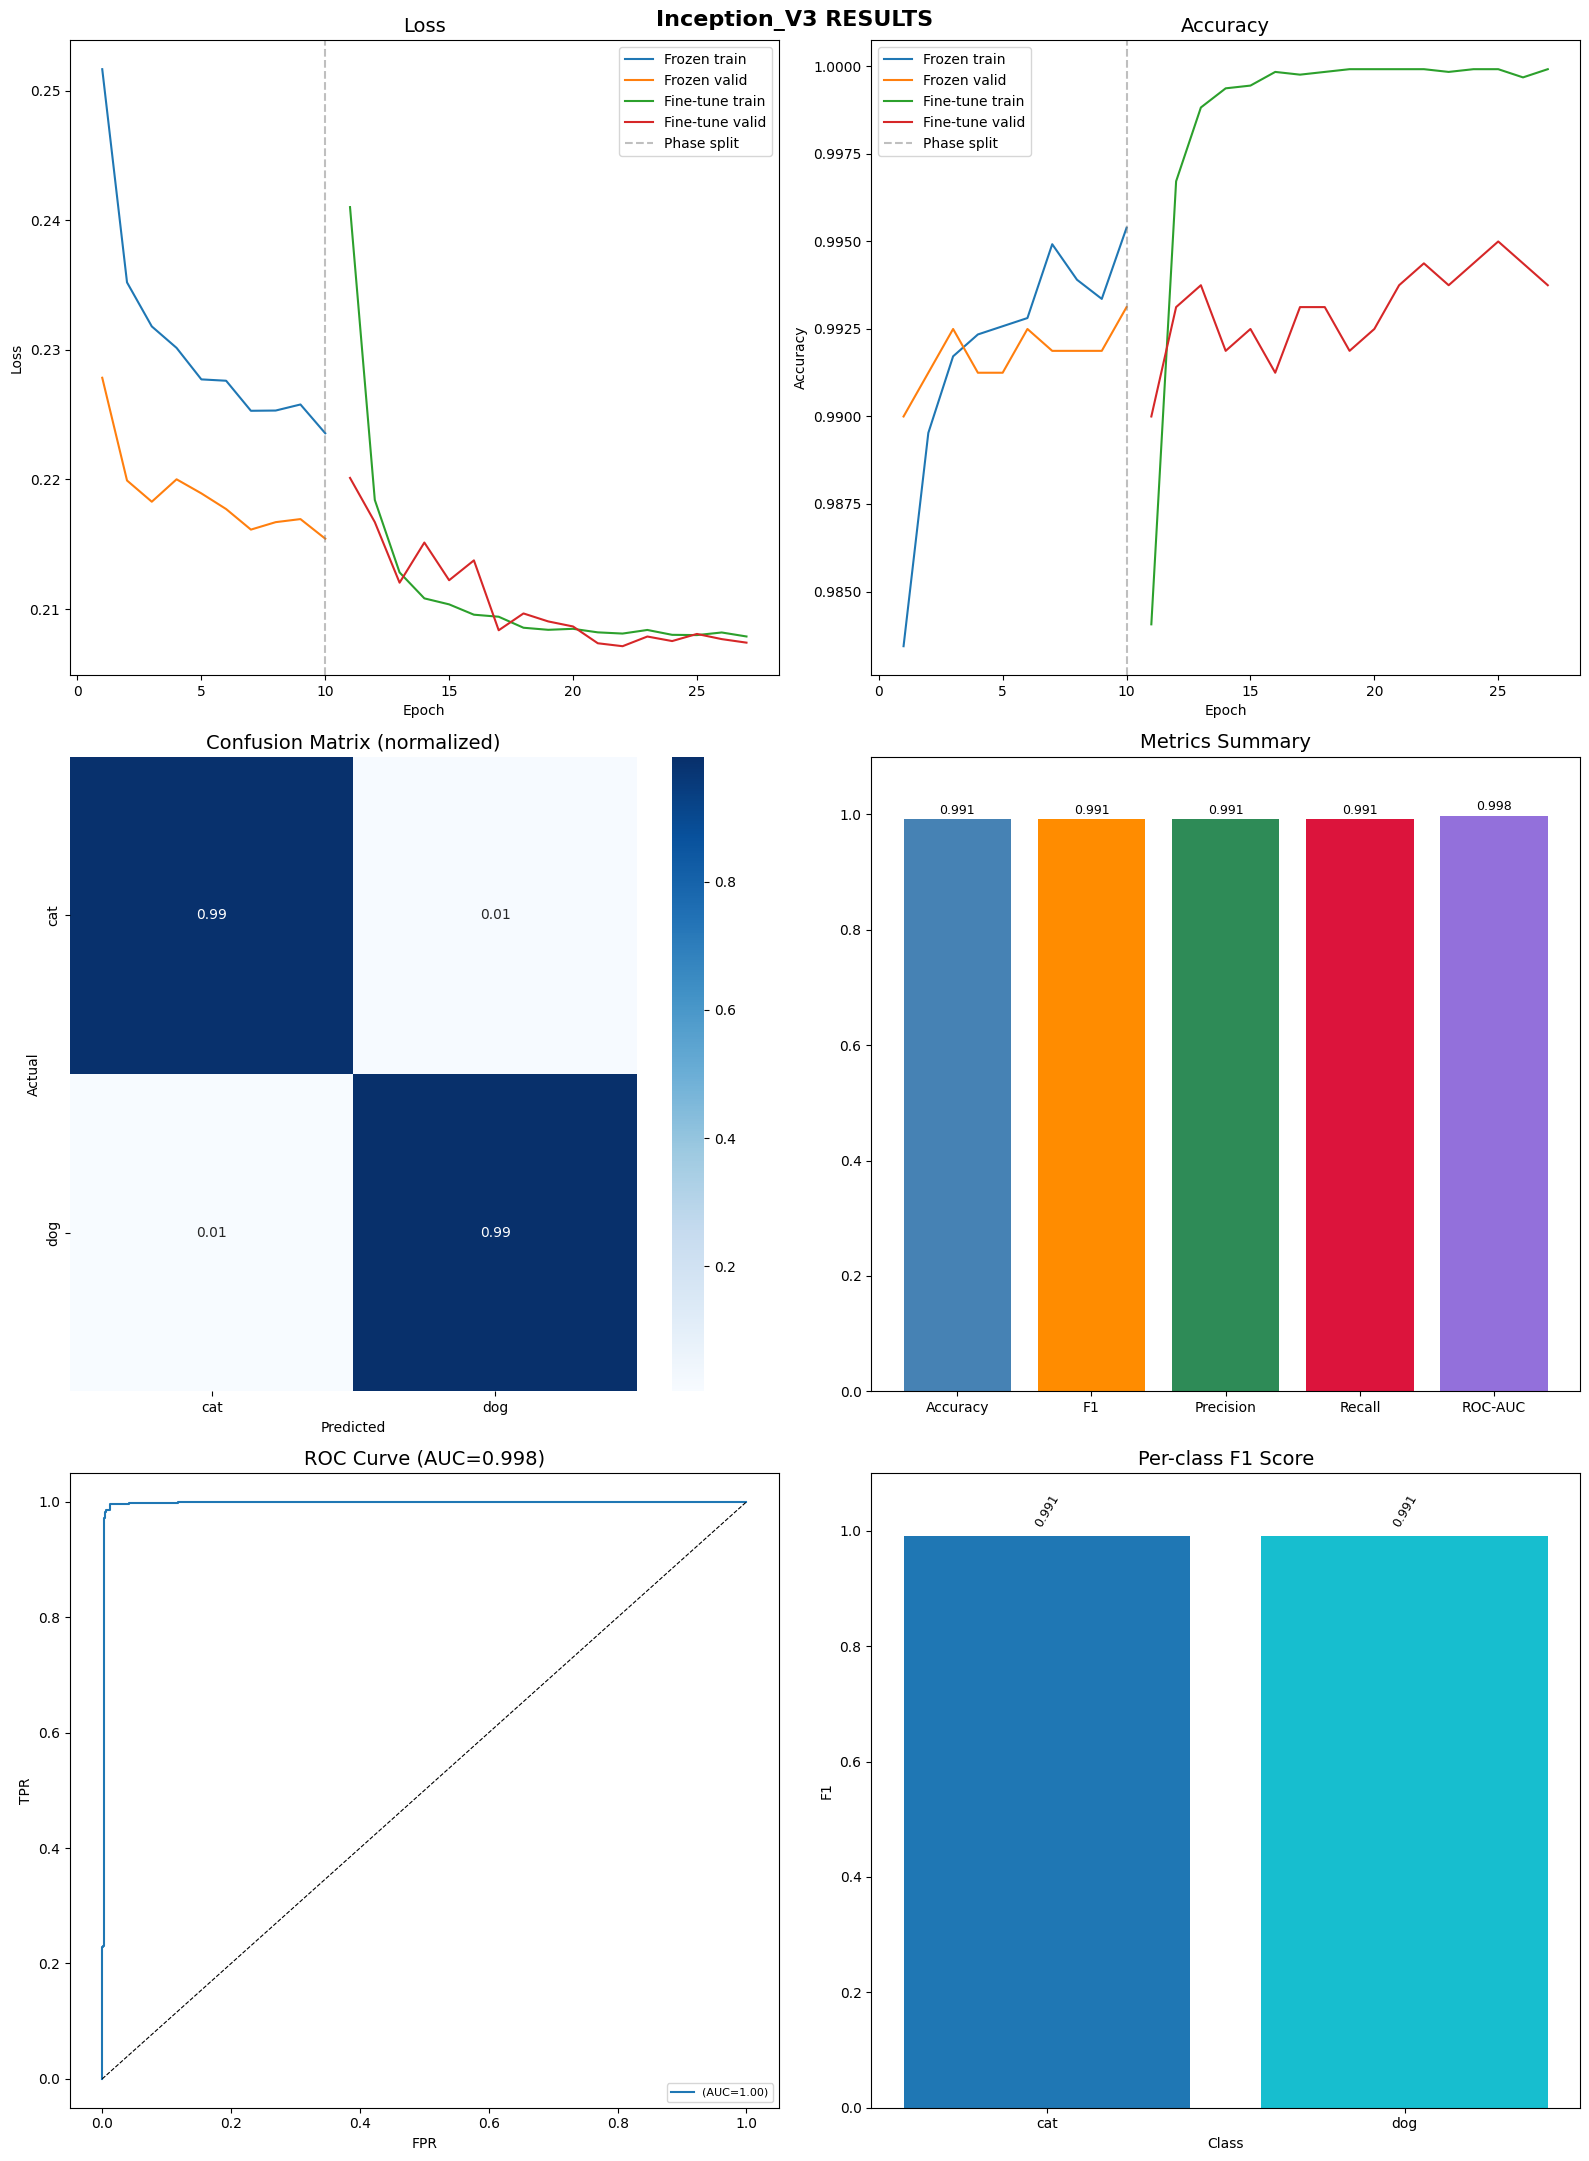

In [20]:
evaluate_model(inceptionv3_model, "Inception_V3", history1, model_save_path_inceptionv3,label1='Frozen', hist2=history2, label2='Fine-tune')

# Wrongly Classified

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


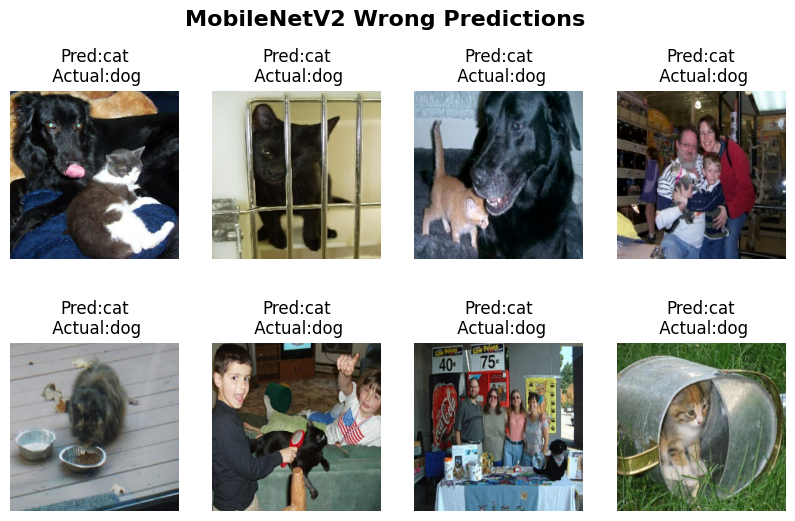

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


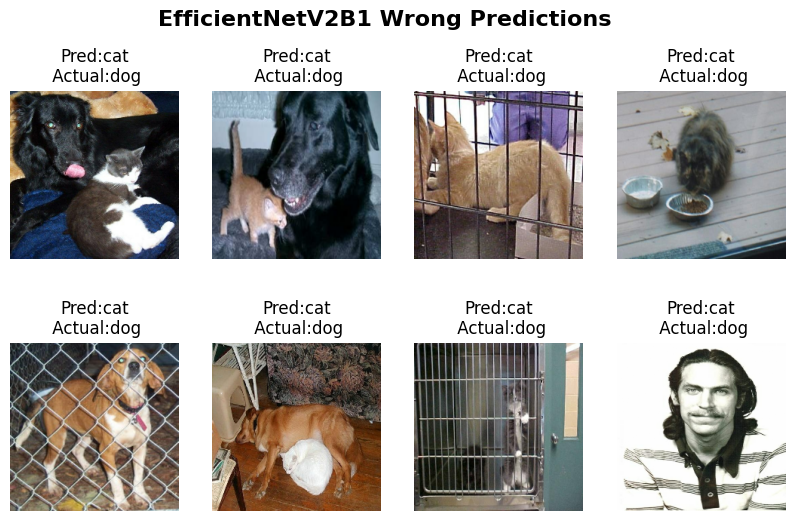

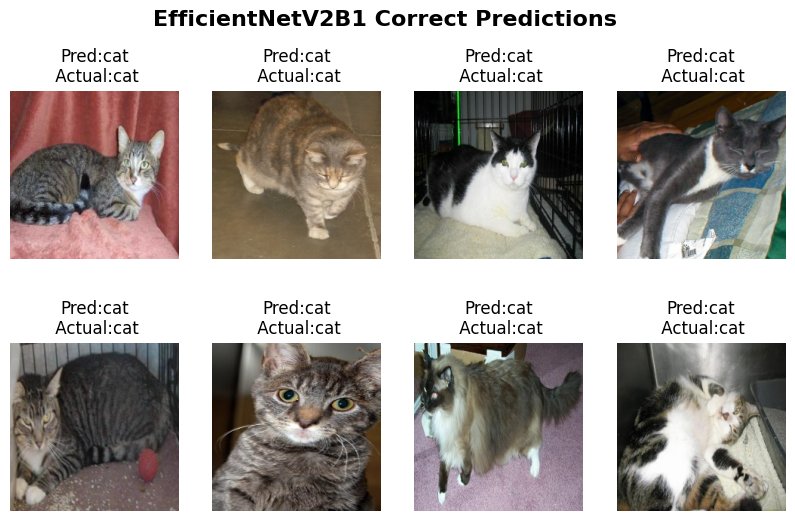

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step


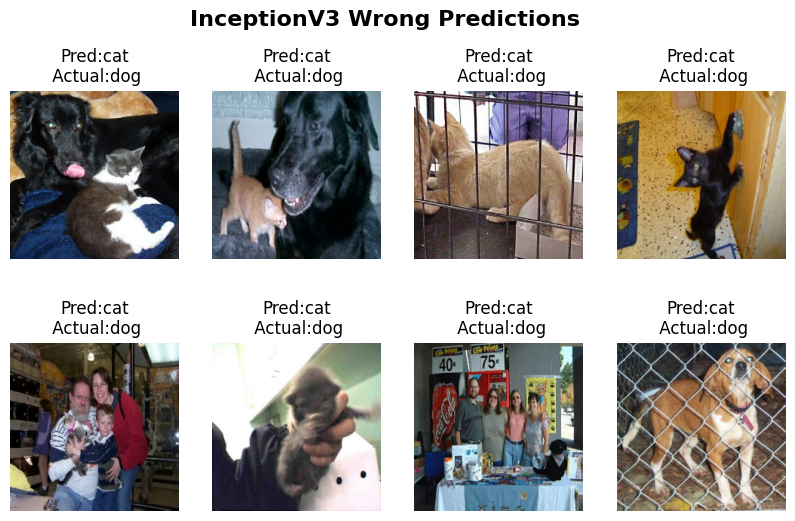

In [21]:
def show_predictions(model, model_name="", show_correctly=False):
    y_pred = model.predict(test_ds)
    y_pred = y_pred.flatten()
    y_pred = [int(y_predi > 0.5) for y_predi in y_pred]
    labels = []
    images = []
    for x, y in test_ds:
        labels.extend([int(yi[0]) for yi in y])
        images.extend(x)

    MAX_SIZE = 8
    wrong_images = []
    wrong_labels = []
    correct_labels = []
    correct_images = []
    for i, (y_predi, yi) in enumerate(zip(y_pred, labels)):
        if y_predi != yi and len(wrong_labels) < MAX_SIZE:
            wrong_images.append(images[i])
            wrong_labels.append(labels[i])
        elif show_correctly and len(correct_labels) < MAX_SIZE:
            correct_images.append(images[i])
            correct_labels.append(labels[i])
            
    fig, axes = plt.subplots(2,4, figsize=(10,6))
    fig.suptitle(f"{model_name} Wrong Predictions", fontsize=16, fontweight="bold")
    axes = axes.flatten()
    for i, (img, y_predi) in enumerate(zip(wrong_images, wrong_labels)):
        axes[i].imshow(img/255.)
        axes[i].set_title(f"Pred:{index_to_class[y_predi]}\n Actual:{index_to_class[abs(1-y_predi)]}")
        axes[i].axis("off")
    plt.show()

    if show_correctly:
        fig, axes = plt.subplots(2,4, figsize=(10,6))
        fig.suptitle(f"{model_name} Correct Predictions", fontsize=16, fontweight="bold")
        axes = axes.flatten()
        for i, (img, y_predi) in enumerate(zip(correct_images, correct_labels)):
            axes[i].imshow(img/255.)
            axes[i].set_title(f"Pred:{index_to_class[y_predi]}\n Actual:{index_to_class[y_predi]}")
            axes[i].axis("off")
        plt.show()
show_predictions(mobilenetv2_model, "MobileNetV2", False)
show_predictions(efficientnetv2b1_model, "EfficientNetV2B1", True)
show_predictions(inceptionv3_model, "InceptionV3", False)

# This is an incredibly important section, and here it shows why. Some of the data is of low quality,
# meaning that we can see that there are cats and dogs in the same image, some images are not relevant 
# and don't even have an animal, or they are wrongly classified. This is very valuable information 
# when making a recommendation since in cases of similar results in metrics that have to do with 
# accuracy, the difference becomes negligible. It's also important because it shows a way that 
# the models can be improved, simply by reviewing the data and fixing these problematic instances.

# Results Analysis

### Results Table

| Model            | Accuracy   | F1 Score   | Precision  | Recall     | ROC-AUC    | Inference (ms/sample) | Model Size (MB) |
|------------------|------------|------------|------------|------------|------------|----------------------|-----------------|
| MobileNetV2      | 99.00%     | 0.9900     | **0.9901** | 0.9900     | 0.9984     | **3.83**             | **23.92**       |
| EfficientNetV2B1 | **99.25%** | **0.9925** | **0.9925** | **0.9925** | **0.9990** | 5.78                 | 42.60           |
| InceptionV3      | 99.12%     | 0.9912     | 0.9913     | 0.9912     | 0.9977     | 6.06                 | 141.97          |
** Best results for each column are marked in bold

### Results Analysis (per column)

#### Accuracy
- The percentage of total predictions that the model got correct. We can see that EfficientNetV2B1 got the highest score, however, after seeing some of the samples that were wrongly classified we could see that some images were not relevant for the dataset, either not containing images with cats or dogs, containing images of cats and dogs in the same image, or low quality ones where it was impossible to understand which animal it is. Due to this information, presented in the section "Wrongly Classified", it's very hard to determine which model did the best hence I would not place such a big emphasis on the fact that EfficientNetV2B1 got the highest score and say that since they all got similar scores with the largest margin being 0.25%, it would not influence my decision in making a recommendation.

#### F1 Score
- A harmonic mean of Precision and Recall. Not too relevant due to the explanation presented in Accuracy about the quality of the dataset. They all got similar scores with the biggest margin being 0.25% therefore it wouldn't be influencing my decision in making a recommendation.

#### Precision
- Of all the samples the model predicted positive, how many were actually positive. Not too relevant due to the explanation presented in Accuracy about the quality of the dataset. They all got similar scores with the biggest margin being 0.25% therefore it wouldn't be influencing my decision in making a recommendation.

#### Recall
- Of all the actual positive samples, how many the model correctly identified. Not too relevant due to the explanation presented in Accuracy about the quality of the dataset. They all got similar scores with the biggest margin being 0.25% therefore it wouldn't be influencing my decision in making a recommendation.

#### ROC-AUC
- Measures how well the model distinguishes between classes across all possible decision thresholds. Also not relevant for making a recommendation, they all got a similar score which was very close to 100%.

#### Inference
- MobileNetV2 has the lowest inference time of 3.83 ms/sample which is a significant decrease from the second lowest of EfficientNetV2B1 with 5.78 ms/sample, giving almost a 2ms margin which is actually helpful for picking a model. Lower inference time is very important in mobile devices, or in any project that needs to work quickly, I will place a lot of emphasis on it.

#### ModelSize
- MobileNetV2 has the lowest size with roughly 24MB, followed by EfficientNetV2B1 with roughly 43MB, almost the double, with InceptionV3 as the last one with roughly 142MB. Having a small size is a critical criteria when making a model for mobile devices where storage is a limited resource, so I will place a lot of emphasis on the model's size as well.

#### *SideNotes
- As you can see a lot of the metrics became largely irrelevant due to the fact that the dataset has some problematic data such as images that were low quality/wrongly mismatched/not relevant. In order to treat this problem, I would either look for a higher quality dataset where the data has been verified. Another option would also be to manually pass through the data and filter it. Another solution would be to ignore it (as long as the relative size of problematic data is not too big), since problematic data/anomalies are not causing an issue as long they are in relatively small sizes.

- I would also like to mention here again, when picking the models, often there was a trade between accuracy and size, the heavier models such as InceptionV3 usually came with a higher accuracy, something that didn't manifest in this project I would assume due to lack of necessity of extra complexity, however in other projects it might not be the case and we will see these heavier models perform better in accuracy/precision and so on...

### Personal Recommendation for model to use

I would recommend MobileNetV2, since all the models have around the same scores in Accuracy, F1 Score, Precision, Recall, ROC-AUC, and we are also aware of problematic data, the metrics which are taken into consideration when making the recommendation are the inference time and the model size.

Since MobileNetV2 has the lowest inference time by a margin of almost 2ms from the next and has the lowest size, being almost twice as small as the next smallest model, I would say that it's the natural choice.

# Conclusion

In this project I did binary classification trying to separate cat and dog images. I built 3 models using transfer learning and fine tuning using MobileNetV2, EfficientNetV2B1, and InceptionV3 as backbone models.

In the end I compared the results in the "Results Analysis" section where I went over every metric slightly explaining who is the best model in that category while also writing the significance of the metric and how it helps make a final recommendation.

After making the results analysis I presented some of the images that each model got wrong to understand better whether it was the models' fault or whether the images were wrongly classified in the dataset, helping me understand better how I can improve my models (explained more in detail earlier at that section).

### Planning & Process

The emphasis in this project was the planning and the structured planning beforehand. In the beginning the plan was to work with 3 datasets and to make a plain CNN model as well as the 3 transfer learning models, however, due to the fact that the first (current) dataset contained sufficient information and the other datasets had very clean data (easier to classify), I opted with just keeping the one currently being used. 

The CNN model's part is still present in the project commented out since I thought it would be relevant to document why it was ruled out (more detailed explanation at "CNN Model" section. 

As you can see the planning changed throughout the project however the majority of things still remained the same and this planning and organizing helped me make this project much faster than the ones I had done before.

### Implementation highlights

Some things that were in this project and weren't in others before were the organizing into functions, which I found very helpful in terms of keeping everything structured and easy to change. Working with a single neuron with sigmoid instead of 2 using softmax, which looked very simple but required adjusting and changing a lot of things (like for example the tf datasets, the evaluation function...), I had to do some research to figure out which one I should use, I found that the weight difference was negligible, but it made the architecture cleaner and more standard.

Adding the weight metric to the evaluation function as well was also very useful since it's a metric that's very relevant when measuring the models and ultimately making a recommendation.

### Results

After the results analysis (section "Results Analysis") I made a recommendation on picking MobileNetV2 since it's the lightest and fastest, making it a very solid choice considering the circumstances (low quality data presented in the section before). The other models were very close however, it seems like there was no need for heavier models in this project as the data was not too complex to require it.

### What I learned

I learned how to work in a more organized manner. Planning everything beforehand and making sure that everything is structured and documented was making things simpler and more professional. 

In terms of technical things that I learned, understanding why the CNN model didn't work also helped me understand some of the difficulties that can be encountered when making models with a lot of layers. 

During the project I also had to deal with the image preprocessing since some of the images had 2 channels which gave errors later on if they were stored without treatment, and also image corruption which has appeared when I was trying to use multiple datasets and I needed to understand what it meant as well as possible solutions (decided to only keep the original as it was sufficient for training the models).

### What I'd do differently

In the next project, knowing a little more about the technical difficulties that might come up I might decide to divide the project in sections so that I can adjust the next section based on the current one, knowing that unexpected problems/complications can change the structure later on. 

I would also like to move to more advanced projects I would be using data augmentation or another type of model since I think it will be helpful later on (learning how to work with different documentations is a skill that has a lot of value).

Hope you enjoyed the project! 

The End!